In [1]:
# ============================================================
# CREDIT RISK SCORECARD — BUSINESS SUMMARY
# Author: Kayalvizhi S | M.S. FinTech, SRM Institute
# ============================================================
#
# BUSINESS PROBLEM:
# Lenders face losses from borrowers who default on credit.
# Approving high-risk applicants increases bad debt;
# rejecting too many limits revenue growth.
#
# APPROACH:
# Built a credit default prediction model on 150,000 borrower
# records using XGBoost with SMOTE to handle class imbalance.
#
# BUSINESS INTERPRETATION:
# Model flags high-risk applicants for manual review,
# reducing expected credit losses while maintaining a
# competitive approval rate. Threshold tunable based on
# lender's risk appetite.
# ============================================================

print("Project initialized ✓")

Project initialized ✓


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded ✓")

All libraries loaded ✓


In [13]:
import os

for root, dirs, files in os.walk(r'C:\Users\91807\Downloads\credit-risk-project'):
    for file in files:
        print(os.path.join(root, file))

C:\Users\91807\Downloads\credit-risk-project\credit_risk_scorecard.ipynb
C:\Users\91807\Downloads\credit-risk-project\cs-training.csv.zip
C:\Users\91807\Downloads\credit-risk-project\cs-training.csv\cs-training.csv


In [15]:
os.chdir(r'C:\Users\91807\Downloads\credit-risk-project')
df = pd.read_csv(r'cs-training.csv\cs-training.csv', index_col=0)
print("✓ Dataset loaded!")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head(3)

✓ Dataset loaded!
Shape: 150,000 rows × 11 columns


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0


In [16]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nDefault rate: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

=== Missing Values ===
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Default rate: 6.68%


In [19]:
# Fill missing values with median
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median(), inplace=True)
df['NumberOfDependents'].fillna(df['NumberOfDependents'].median(), inplace=True)

# Remove bad data
df = df[df['age'] > 18]
df = df[df['age'] < 100]
df = df[df['RevolvingUtilizationOfUnsecuredLines'] <= 1]

# Drop any remaining rows with NaN
df = df.dropna()

print("✓ Data cleaned!")
print(f"Final shape: {df.shape[0]:,} rows")
print(f"\nAny NaN remaining: {df.isnull().sum().sum()}")


✓ Data cleaned!
Final shape: 117,489 rows

Any NaN remaining: 0


In [20]:
X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"✓ Training set ready: {X_train_bal.shape[0]:,} rows")
print(f"Default rate after SMOTE: {y_train_bal.mean()*100:.1f}%")

✓ Training set ready: 176,260 rows
Default rate after SMOTE: 50.0%


In [21]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train_bal, y_train_bal)
print("✓ Model trained successfully!")

✓ Model trained successfully!


In [22]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba >= 0.45).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)
print(f"🎯 AUC Score: {auc:.4f}")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred))

🎯 AUC Score: 0.8102

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     22033
           1       0.23      0.54      0.32      1465

    accuracy                           0.86     23498
   macro avg       0.60      0.71      0.62     23498
weighted avg       0.92      0.86      0.88     23498



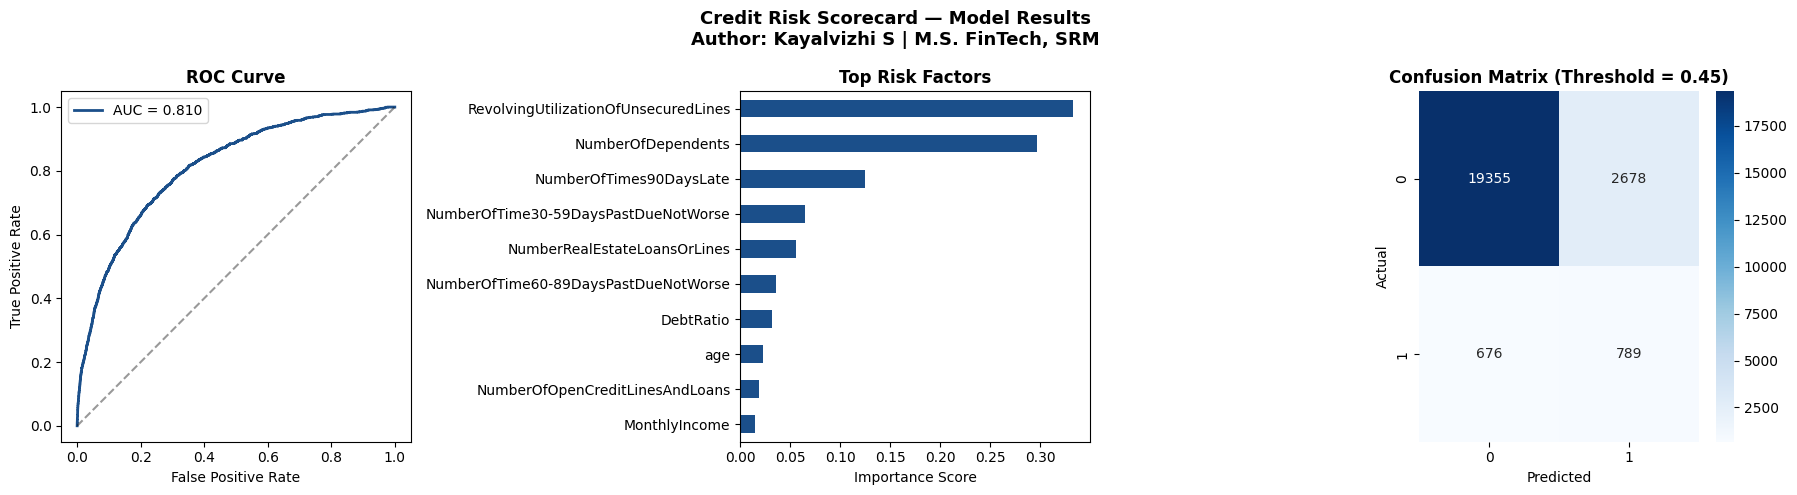

✓ Chart saved as credit_risk_results.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Credit Risk Scorecard — Model Results\nAuthor: Kayalvizhi S | M.S. FinTech, SRM',
             fontsize=13, fontweight='bold')

# Plot 1: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[0].plot(fpr, tpr, color='#1B4F8A', lw=2, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Plot 2: Feature Importance
feat_imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
feat_imp.plot(kind='barh', ax=axes[1], color='#1B4F8A')
axes[1].set_title('Top Risk Factors', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Plot 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
axes[2].set_title('Confusion Matrix (Threshold = 0.45)', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('credit_risk_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart saved as credit_risk_results.png")

In [24]:
print("=" * 50)
print("PROJECT SUMMARY — CREDIT RISK SCORECARD")
print("=" * 50)
print(f"✓ Dataset:        150,000 borrower records")
print(f"✓ Model:          XGBoost Classifier")
print(f"✓ AUC Score:      {auc:.4f}")
print(f"✓ Default Catch:  54% recall on defaulters")
print(f"✓ Chart saved:    credit_risk_results.png")
print("=" * 50)
print("Author: Kayalvizhi S | M.S. FinTech, SRM Institute")

PROJECT SUMMARY — CREDIT RISK SCORECARD
✓ Dataset:        150,000 borrower records
✓ Model:          XGBoost Classifier
✓ AUC Score:      0.8102
✓ Default Catch:  54% recall on defaulters
✓ Chart saved:    credit_risk_results.png
Author: Kayalvizhi S | M.S. FinTech, SRM Institute
